In [7]:
pip install keras_nlp

In [8]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import keras_nlp

In [9]:
imdb , info = tfds.load("imdb_reviews", as_supervised=True, with_info=True, download=True, data_dir="./data")

In [10]:
train_reviews = imdb['train'].map(lambda review, label: review)
train_labels = imdb['train'].map(lambda review, label: label)

test_reviews = imdb['test'].map(lambda review, label: review)
test_labels = imdb['test'].map(lambda review, label: label)

In [11]:
VOCAB_SIZE = 10000
MAX_LEN = 120
pad = "pre"
Trunc = "post"

In [14]:
# Instantiate the vectorization layer
vectorize_layer = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE
)

# Generate the vocabulary based only on the training set
vectorize_layer.adapt(train_reviews)

In [18]:
def padding_func(sequences):
  '''Generates padded sequences from a tf.data.Dataset'''

  # Put all elements in a single ragged batch
  sequences = sequences.ragged_batch(batch_size=sequences.cardinality())

  # Output a tensor from the single batch
  sequences = sequences.get_single_element()

  # Pad the sequences
  padded_sequences = tf.keras.utils.pad_sequences(sequences.numpy(),
                                                  maxlen=MAX_LEN,
                                                  truncating=Trunc,
                                                  padding=pad
                                                 )

  # Convert back to a tf.data.Dataset
  padded_sequences = tf.data.Dataset.from_tensor_slices(padded_sequences)

  return padded_sequences

In [19]:
train_sequences = train_reviews.map(lambda x: vectorize_layer(x)).apply(padding_func)
train_sequences

<_TensorSliceDataset element_spec=TensorSpec(shape=(120,), dtype=tf.int32, name=None)>

In [20]:
full_vocab = vectorize_layer.get_vocabulary()
sample_sequences = train_sequences.take(1).get_single_element()
decode = [full_vocab[i] for i in sample_sequences]
decode = " ".join(decode)
print(decode)

    this was an absolutely terrible movie dont be [UNK] in by christopher walken or michael [UNK] both are great actors but this must simply be their worst role in history even their great acting could not redeem this movies ridiculous storyline this movie is an early nineties us propaganda piece the most pathetic scenes were those when the [UNK] rebels were making their cases for [UNK] maria [UNK] [UNK] appeared phony and her [UNK] affair with walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning i am disappointed that there are movies like this ruining actors like christopher [UNK] good name i could barely sit through it


In [21]:
keras_nlp.tokenizers.compute_word_piece_vocabulary(train_reviews, 1000, reserved_tokens=["[PAD]", "[UNK]"], vocabulary_output_file="imdb_vocab_subwords.txt")


In [22]:
subwords_tokenizer = keras_nlp.tokenizers.WordPieceTokenizer(vocabulary="imdb_vocab_subwords.txt")

In [33]:
# Print the subwords
subwords_tokenizer.get_vocabulary()

['[PAD]',
 '[UNK]',
 '!',
 '"',
 '#',
 '$',
 '%',
 '&',
 "'",
 '(',
 ')',
 '*',
 '+',
 ',',
 '-',
 '.',
 '/',
 '0',
 '1',
 '2',
 '3',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 ':',
 ';',
 '<',
 '=',
 '>',
 '?',
 '@',
 'A',
 'B',
 'C',
 'D',
 'E',
 'F',
 'G',
 'H',
 'I',
 'J',
 'K',
 'L',
 'M',
 'N',
 'O',
 'P',
 'Q',
 'R',
 'S',
 'T',
 'U',
 'V',
 'W',
 'X',
 'Y',
 'Z',
 '[',
 '\\',
 ']',
 '^',
 '_',
 '`',
 'a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z',
 '{',
 '|',
 '}',
 '~',
 '',
 '¡',
 '¢',
 '£',
 '¤',
 '¦',
 '§',
 '¨',
 '«',
 '®',
 '°',
 '³',
 '´',
 '·',
 'º',
 '»',
 '½',
 '¾',
 '¿',
 'À',
 'Á',
 'Ã',
 'Ä',
 'Å',
 'È',
 'É',
 'Ê',
 'Õ',
 'Ø',
 'Ü',
 'ß',
 'à',
 'á',
 'â',
 'ã',
 'ä',
 'å',
 'æ',
 'ç',
 'è',
 'é',
 'ê',
 'ë',
 'ì',
 'í',
 'î',
 'ï',
 'ð',
 'ñ',
 'ò',
 'ó',
 'ô',
 'ö',
 'ø',
 'ù',
 'ú',
 'û',
 'ü',
 'ý',
 'ō',
 '–',
 '‘',
 '’',
 '“',
 '”',
 '…',
 '₤',
 '\uf0b7',
 't

In [31]:
subwords_tokenizer.vocabulary_size()

981

In [25]:
# Get a sample review
sample_review = train_reviews.take(1).get_single_element()

# Encode the first plaintext sentence using the subword text encoder
tokenized_string = subwords_tokenizer.tokenize(sample_review)
print ('Tokenized string is {}'.format(tokenized_string))

# Decode the sequence
original_string = subwords_tokenizer.detokenize(tokenized_string)

# Print the result
print('The original string: {}'.format(original_string))

Tokenized string is [225 178 208  66 382 166 200 257 670 179  85 195 605 182  15  37 207   8
  85 199  77 369 176 171 204  36 224 193 381 485 466  56 209 589 187 219
  46 217 224 203 505  42 193 819 351  15  35 401 224 194 294 434  13 188
 175 547  84 829 199 260 657 544 171 197 190 498  15  38 634 260 294 352
 308 196 430 576 191 273 175 182   8  84  83 274 217 617 257 329 249 257
 275  15 225 182 169 208  70 637  79 275 190 265  54 442  81 193 485 203
 255 342 203  81 727  15 180 301  81 322 224 341 217 398 267 436 246 164
  36 200 257 764 382 391 430 482 257 166 267 591 260  68 419 166 184 430
 908 200 257 675 575  15  46 262 405  36 207 268 283 203  34 257 819 200
  66 291 291 767 177  81 224 207 185  13 165 218  81 489 617 176 200  14
 374  66 557 696 183  56 209 589 187 178 487 188  66  81 322 224 341 217
  70 273 401 232 209  81 257 617 255 171  66 182 174 178  69 191 908 200
 274 167 318 425 269 214 173  15  42 622  69 330 755 291 200 264 320 174
 240 194 315 213 175  13  83 61

In [29]:
# Define sample sentence
sample_string = 'TensorFlow, from basics to mastery'

# Encode using the plain text tokenizer
tokenized_string = vectorize_layer(sample_string)
print ('Tokenized string is {}'.format(tokenized_string))

# Decode and print the result
decoded_text = [full_vocab[token] for token in tokenized_string]
original_string = ' '.join(decoded_text)
print ('The original string: {}'.format(original_string))

Tokenized string is [ 1 36  1  6  1]
The original string: [UNK] from [UNK] to [UNK]


In [35]:
tokenized_string = subwords_tokenizer.tokenize(sample_string)
print('Tokenized string is {}'.format(tokenized_string))

original_string = subwords_tokenizer.detokenize(tokenized_string)
print('The original string: {}'.format(original_string))

Tokenized string is [ 53 311 166 247 885 257 242  13 212  67 513 753 168  78 491 195 185]
The original string: TensorFlow , from basics to mastery


In [39]:
# Show token to subword mapping:
for ts in tokenized_string:
  print ('{} ----> {}'.format(ts, subwords_tokenizer.detokenize([ts])))

53 ----> T
311 ----> ##en
166 ----> ##s
247 ----> ##or
885 ----> ##F
257 ----> ##l
242 ----> ##ow
13 ----> ,
212 ----> from
67 ----> b
513 ----> ##as
753 ----> ##ics
168 ----> to
78 ----> m
491 ----> ##ast
195 ----> ##er
185 ----> ##y


In [40]:
SHUFFLE_BUFFER_SIZE = 10000
PREFETCH_BUFFER_SIZE = tf.data.AUTOTUNE
BATCH_SIZE = 32

# Generate integer sequences using the subword tokenizer
train_sequences_subword = train_reviews.map(lambda review: subwords_tokenizer.tokenize(review)).apply(padding_func)
test_sequences_subword = test_reviews.map(lambda review: subwords_tokenizer.tokenize(review)).apply(padding_func)

# Combine the integer sequence and labels
train_dataset_vectorized = tf.data.Dataset.zip(train_sequences_subword,train_labels)
test_dataset_vectorized = tf.data.Dataset.zip(test_sequences_subword,test_labels)

# Optimize the datasets for training
train_dataset_final = (train_dataset_vectorized
                       .shuffle(SHUFFLE_BUFFER_SIZE)
                       .cache()
                       .prefetch(buffer_size=PREFETCH_BUFFER_SIZE)
                       .batch(BATCH_SIZE)
                       )

test_dataset_final = (test_dataset_vectorized
                      .cache()
                      .prefetch(buffer_size=PREFETCH_BUFFER_SIZE)
                      .batch(BATCH_SIZE)
                      )

In [41]:
# Define dimensionality of the embedding
EMBEDDING_DIM = 64

# Build the model
model = tf.keras.Sequential([
    tf.keras.Input(shape=(MAX_LEN,)),
    tf.keras.layers.Embedding(subwords_tokenizer.vocabulary_size(), EMBEDDING_DIM),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(6, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Print the model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 120, 64)        │        62,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,181 (246.80 KB)

 Trainable params: 63,181 (246.80 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
num_epochs = 10

# Set the training parameters
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

# Start training
history = model.fit(train_dataset_final, epochs=num_epochs, validation_data=test_dataset_final)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.6586 - loss: 0.6113 - val_accuracy: 0.7094 - val_loss: 0.5595
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7331 - loss: 0.5253 - val_accuracy: 0.7187 - val_loss: 0.5452
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7400 - loss: 0.5140 - val_accuracy: 0.7218 - val_loss: 0.5425
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7424 - loss: 0.5100 - val_accuracy: 0.7224 - val_loss: 0.5412
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7438 - loss: 0.5078 - val_accuracy: 0.7218 - val_loss: 0.5408
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7443 - loss: 0.5065 - val_accuracy: 0.7217 - val_loss: 0.5404
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7449 - loss: 0.5055 - val_accuracy: 0.7220 - val_loss: 0.5401
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7458 - loss: 0.5047 - val_accuracy: 

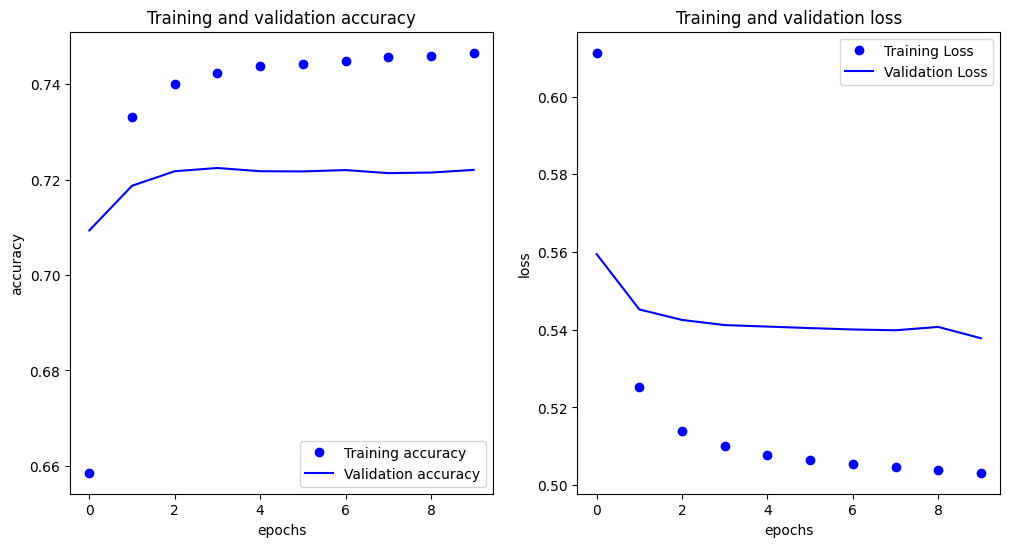

In [44]:
def plot_loss_acc(history):
  '''Plots the training and validation loss and accuracy from a history object'''
  acc = history.history['accuracy']
  val_acc = history.history['val_accuracy']
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  epochs = range(len(acc))

  fig, ax = plt.subplots(1,2, figsize=(12, 6))
  ax[0].plot(epochs, acc, 'bo', label='Training accuracy')
  ax[0].plot(epochs, val_acc, 'b', label='Validation accuracy')
  ax[0].set_title('Training and validation accuracy')
  ax[0].set_xlabel('epochs')
  ax[0].set_ylabel('accuracy')
  ax[0].legend()

  ax[1].plot(epochs, loss, 'bo', label='Training Loss')
  ax[1].plot(epochs, val_loss, 'b', label='Validation Loss')
  ax[1].set_title('Training and validation loss')
  ax[1].set_xlabel('epochs')
  ax[1].set_ylabel('loss')
  ax[1].legend()

  plt.show()

plot_loss_acc(history)